In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches

In [3]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.5       # 质量项
A = 1.0        # 费米速度项
B = 0.5        # 二阶动量项
Bz = 0.005  # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 50
xshumu = yshumu

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)


if m * B < 0:
    leiN = 1  # Topological
else:
    leiN = 0  # Trivial




Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 1145.02it/s]
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\2.png
图像已保存至: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\2.eps
1


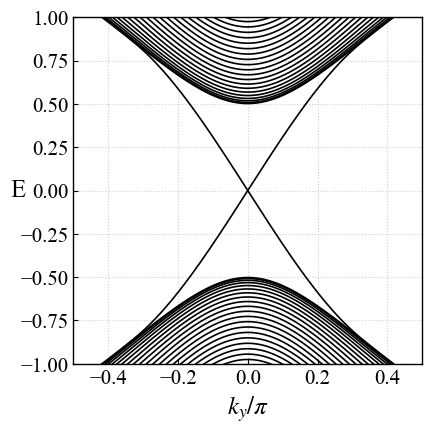

In [ ]:
# 中间能带
Bz = 0.00
T_21 = H_hop(B, a, A, xshumu, Nd, Bz)
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi, 1001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(4.5, 4.5))

for i in range(energies1.shape[1]):
    plt.plot(ks1/np.pi, energies1[:, i], color='black', linewidth=1.2)

plt.ylim(-1, 1)
plt.xlim(-0.5, 0.5)

# ==========================================
# 修改点 1：调整 Y 轴标注距离，并放大字体 1.5 倍
# labelpad 参数控制标注与坐标轴的距离，默认值通常较大
# 设置为较小的正数或负数（如 0 或 -2）可以使其更贴近轴线
# ==========================================
plt.ylabel('E', labelpad=2, rotation=0, va='center', fontsize=18) # 字体放大到 18

plt.xlabel(r'$k_y/\pi$', fontsize=18) # 字体放大到 18

# 新增：放大坐标轴上的刻度数字 (放大到 15)
plt.tick_params(axis='both', which='major', labelsize=15)

plt.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 修改点 2：保存为 eps 格式到指定路径
# ==========================================
save_folder = r"C:\Users\taoji\Desktop\论文写作\2026.5.13"
# 如果文件夹不存在则创建（可选）
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

save_file_path = os.path.join(save_folder, "2.eps")
save_fig_by_title_1("2")
# bbox_inches='tight' 非常重要，它能确保导出的 eps 文件不留白边且标注不被遮挡
plt.savefig(save_file_path, format='eps', bbox_inches='tight')

print(f"图像已保存至: {save_file_path}")
print(leiN)
plt.show()

In [ ]:
#保存
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}"
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

save_dir = rf"C:\Users\taoji\Desktop\论文写作\2026.5.13"
os.makedirs(save_dir, exist_ok=True)

def save_fig_by_title_1(name):
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
    filename = os.path.join(save_dir, safe_name + ".png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")


def save_data_to_txt(x_data, y_data, filename, save_dir, header_text="X_Data\tY_Data"):
    """
    通用 txt 数据保存函数
    :param x_data: x 轴数据 (比如 Bz_values)
    :param y_data: y 轴数据 (比如 G_values)
    :param filename: 保存的文件名 (不需要加 .txt 后缀)
    :param save_dir: 保存的文件夹路径
    :param header_text: txt 文件第一行的表头说明
    """
    # 确保文件夹存在
    os.makedirs(save_dir, exist_ok=True)
    
    # 替换文件名中可能导致报错的非法字符
    safe_name = filename
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
        
    # 拼接完整路径
    filepath = os.path.join(save_dir, safe_name + ".txt")
    
    # 将 x 和 y 拼成两列矩阵
    data_matrix = np.column_stack((x_data, y_data))
    
    # 写入 txt，使用科学计数法保留 8 位小数，以 tab 键分割
    np.savetxt(filepath, data_matrix, fmt='%.8e', delimiter='\t', header=header_text, comments='# ')
    print(f"✅ 数据已成功保存至: {filepath}")

Calculating Bands (Bz=0.008): 100%|██████████| 1001/1001 [00:00<00:00, 1265.59it/s]


已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\leiN=1_m=-0.5_A=1.0_B=0.5_Lx=50_Ly=50_uS=0_Ex=0.png


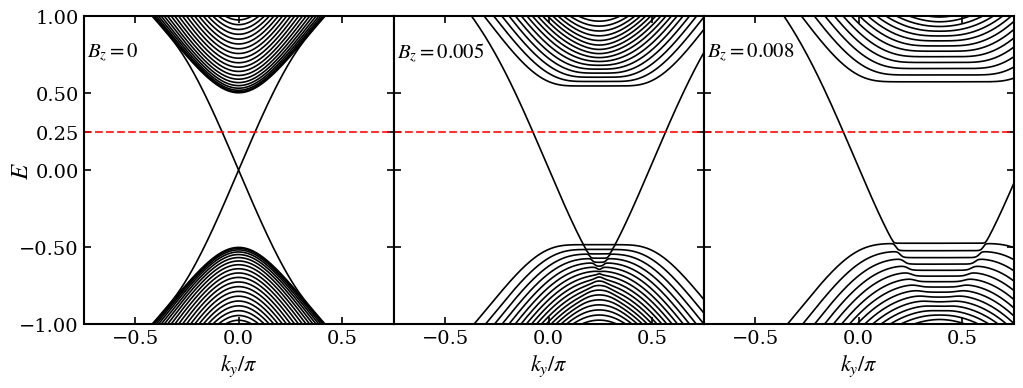

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

# ==========================================
# 0. PRL 级别全局绘图格式美化设置
# ==========================================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 渲染出极其完美的物理公式斜体 (类似 Times New Roman)
mpl.rcParams['axes.linewidth'] = 1.5       # 全局边框加粗
mpl.rcParams['xtick.direction'] = 'in'     # X轴刻度朝内
mpl.rcParams['ytick.direction'] = 'in'     # Y轴刻度朝内
mpl.rcParams['xtick.top'] = True           # 显示上方刻度线
mpl.rcParams['ytick.right'] = True         # 显示右侧刻度线
mpl.rcParams['xtick.major.width'] = 1.2    # X轴刻度线变粗
mpl.rcParams['ytick.major.width'] = 1.2    # Y轴刻度线变粗
mpl.rcParams['xtick.major.size'] = 5       # 刻度线长度
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['font.size'] = 14             # 全局基准字号

# 1. 准备要扫描的 Bz 列表和动量空间
Bz_list = [0, 0.005, 0.008]
ks1 = np.linspace(-1*np.pi, 1*np.pi, 1001)

def Hk(k, H, T):
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

# 2. 创建一个 1行3列 的画布，稍微调整比例使其紧贴后更协调
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 3. 遍历 Bz 列表并分别画在对应的子图上
for idx, Bz in enumerate(Bz_list):
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz)
    energies1 = []
    
    for k in tqdm(ks1, desc=f"Calculating Bands (Bz={Bz})"):
        H_k = Hk(k, H_q, T_21)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)

    energies1 = np.array(energies1)
    ax = axes[idx]
    
    # 画出所有能带
    for i in range(energies1.shape[1]):
        ax.plot(ks1/np.pi, energies1[:, i], color='black', linewidth=1.2)
    
    # 在 E = 0.25 处画一条红色虚线的水平横线
    ax.axhline(y=0.25, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    # 🎯 将 Bz 标签放置在左上角 (0.05, 0.92 为相对图框的比例坐标)
    ax.text(0.01, 0.92, fr'$B_z = {Bz}$', transform=ax.transAxes, 
            fontsize=15, verticalalignment='top')

    # 设置子图的坐标轴限制
    ax.set_ylim(-1, 1)
    ax.set_xlim(-0.75, 0.75)
    
    # X 轴标签每个图都要有
    ax.set_xlabel(r'$k_y/\pi$', fontsize=16)

    y_ticks = [-1, -0.5, 0, 0.25, 0.5, 1]
    ax.set_yticks(y_ticks)
    
    # 🎯 处理 Y 轴的标注逻辑：只保留最左侧的文字和数字
    if idx == 0:
        ax.set_ylabel(r'$E$', fontsize=18, labelpad=-10)
    else:
        # 隐藏第2和第3个图的 Y 轴数字刻度，但保留刻度线本身 (朝内)
        ax.set_yticklabels([]) 
        
    # 取消网格线，PRL 风格的能带图通常不带虚线网格以保持画面极致干净
    # 但如果你坚决要保留，可以取消下面这行的注释
    # ax.grid(True, linestyle=':', alpha=0.6)

# 🎯 核心修改：让三个子图完全紧贴在一起，间隙为 0
plt.subplots_adjust(wspace=0.0)

# 显示图像
save_fig_by_title_1(params_str)
plt.show()

In [11]:
import numpy as np
from tqdm import tqdm

# 1. 设定要计算的目标能量和磁场列表
E_target = 0.25
Bz_list = [0.0]

# 为了保证极高的精度，我们可以把 k 点撒得密一点 (例如 5000 个点)
ks_dense = np.linspace(-np.pi, np.pi, 5000)

def Hk(k, H, T):
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

print(f"开始计算 E = {E_target} 时的精确 k_y 值...\n")

for Bz in Bz_list:
    # 重新生成当前 Bz 下的层间跃迁矩阵
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz)
    
    energies = []
    # 计算当前磁场下的所有能带
    for k in ks_dense:
        H_k = Hk(k, H_q, T_21)
        evals = np.linalg.eigvalsh(H_k)
        energies.append(evals)

    energies = np.array(energies)
    
    crossings = []
    
    # 2. 遍历所有能带，寻找与 E=0.25 的交点
    for i in range(energies.shape[1]):
        # 将能带整体减去 0.25，转化为找零点问题
        diff = energies[:, i] - E_target
        
        # 寻找符号发生改变的相邻两个点 (即穿过 0 的地方)
        cross_idx = np.where(np.diff(np.sign(diff)))[0]
        
        for idx in cross_idx:
            # 3. 使用线性插值计算极其精确的 k 值
            k1, k2 = ks_dense[idx], ks_dense[idx+1]
            e1, e2 = diff[idx], diff[idx+1]
            
            k_cross = k1 - e1 * (k2 - k1) / (e2 - e1)
            crossings.append(k_cross)
            
    # 排序交点
    crossings = np.sort(crossings)
    
    # 筛选出负 k 和 正 k
    neg_k = [k for k in crossings if k < 0]
    pos_k = [k for k in crossings if k > 0]
    
    # 打印结果
    print(f"===== Bz = {Bz} =====")
    if len(neg_k) > 0 and len(pos_k) > 0:
        # 选取最靠近中心的两个交点 (对应手性边缘态)
        print(f"负 ky = {neg_k[-1]:.6f}  (即 {neg_k[-1]/np.pi:.6f} π)")
        print(f"正 ky = {pos_k[0]:.6f}  (即 {pos_k[0]/np.pi:.6f} π)\n")
    else:
        print("未在该能量处找到对应的 k 点！\n")

开始计算 E = 0.25 时的精确 k_y 值...

===== Bz = 0.0 =====
负 ky = -0.252680  (即 -0.080431 π)
正 ky = 0.252680  (即 0.080431 π)



开始计算指定 k 和 E 的波函数...
k = -0.080431 π: 找到的实际能量 E = 0.250001, <X> = 0.3942
k = +0.080431 π: 找到的实际能量 E = 0.250001, <X> = 48.6058
已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\3.png


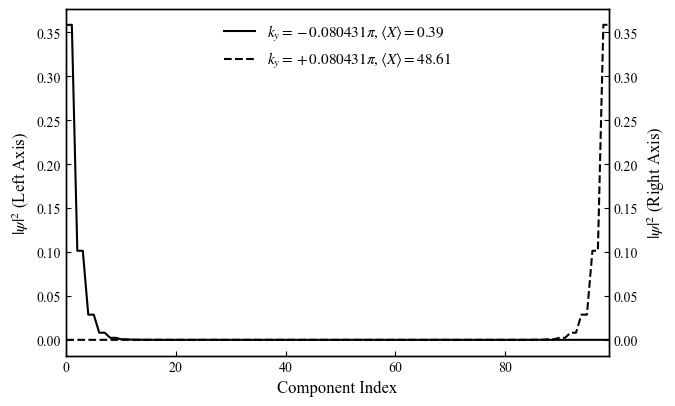

波函数对比图已保存至: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\3.eps


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib

# ==========================================
# 物理期刊全局格式设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] # 优先使用 Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学公式字体类似 Times
plt.rcParams['xtick.direction'] = 'in'           # 刻度线朝内
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.linewidth'] = 1.0             # 边框粗细

# 参数设置
Nd = 2
E_target = 0.25
k_targets = [-0.080431 * np.pi, 0.080431 * np.pi]

# 存储结果
probs = []
x_exps = []
actual_Es = []

print("开始计算指定 k 和 E 的波函数...")

# ==========================================
# 1. 计算两个目标态的波函数
# ==========================================
for k_val in k_targets:
    H_k0 = Hk(k_val, H_q, T_21)
    evals, evecs = np.linalg.eigh(H_k0)
    
    # 找到最接近 E=0.25 的能级索引
    idx = np.argmin(np.abs(evals - E_target))
    E = evals[idx]
    psi = evecs[:, idx]
    
    # 计算概率并归一化
    prob = np.abs(psi)**2
    prob = prob / np.sum(prob) 
    
    # 计算位置期望值 <X>
    X_weights = np.repeat(np.arange(xshumu), Nd)
    x_exp = np.sum(prob * X_weights)
    
    probs.append(prob)
    x_exps.append(x_exp)
    actual_Es.append(E)
    print(f"k = {k_val/np.pi:+.6f} π: 找到的实际能量 E = {E:.6f}, <X> = {x_exp:.4f}")

# ==========================================
# 2. 绘制符合期刊格式的双 Y 轴图
# ==========================================
fig, ax1 = plt.subplots(figsize=(7, 4.5))
x_positions = np.arange(xshumu * Nd)

# 左轴：负 k (-0.080431 π) -> 黑色实线
line1, = ax1.plot(x_positions, probs[0], color='black', linestyle='-', linewidth=1.5, 
                  label=fr'$k_y = -0.080431\pi, \langle X \rangle = {x_exps[0]:.2f}$')

ax1.set_xlabel('Component Index', fontsize=12)
ax1.set_ylabel(r'$|\psi|^2$ (Left Axis)', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.set_xlim(0, xshumu * Nd - 1)

# 右轴：正 k (0.080431 π) -> 黑色虚线
ax2 = ax1.twinx()
line2, = ax2.plot(x_positions, probs[1], color='black', linestyle='--', linewidth=1.5, 
                  label=fr'$k_y = +0.080431\pi, \langle X \rangle = {x_exps[1]:.2f}$')

ax2.set_ylabel(r'$|\psi|^2$ (Right Axis)', fontsize=12)
ax2.tick_params(axis='y', which='major', labelsize=10, direction='in')

# 如果两个波函数极值差距不大，可以统一 Y 轴范围以方便对比 (可选)
# max_prob = max(np.max(probs[0]), np.max(probs[1]))
# ax1.set_ylim(0, max_prob * 1.1)
# ax2.set_ylim(0, max_prob * 1.1)

# 合并图例并将其放置在图表内部，去掉边框使其更简洁
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', frameon=False, fontsize=11)

# ==========================================
# 3. 保存图片
# ==========================================
save_dir = r"C:\Users\taoji\Desktop\论文写作\2026.5.13"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 按照要求命名为 2_wavefunctions.eps (为了避免覆盖你之前的 2.eps，我加了后缀，你可以自行修改为 3.eps 等)
filepath = os.path.join(save_dir, "3.eps")
save_fig_by_title_1("3")

plt.savefig(filepath, format='eps', dpi=300, bbox_inches='tight')
plt.show()

print(f"波函数对比图已保存至: {filepath}")

开始计算指定 k 和 E 的波函数...
k = -0.080431 π: 找到的实际能量 E = 0.250001, <X> = 0.3942
k = +0.080431 π: 找到的实际能量 E = 0.250001, <X> = 48.6058
已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\3.png


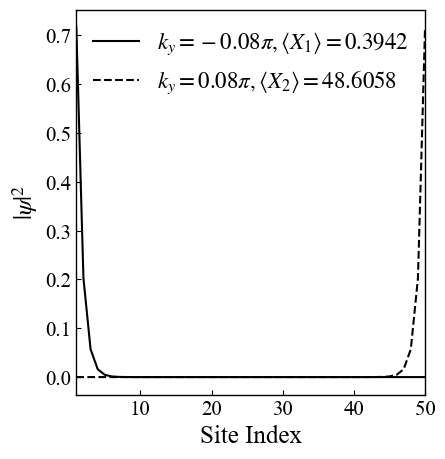

波函数对比图已保存至: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\3.eps


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib

# ==========================================
# 物理期刊全局格式设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] # 优先使用 Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学公式字体类似 Times
plt.rcParams['xtick.direction'] = 'in'           # 刻度线朝内
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.linewidth'] = 1.0             # 边框粗细

# 参数设置
Nd = 2
E_target = 0.25
k_targets = [-0.080431 * np.pi, 0.080431 * np.pi]

# 存储结果
probs_site = [] # 用于存储合并后的每个位置(site)的概率
x_exps = []
actual_Es = []

print("开始计算指定 k 和 E 的波函数...")

# ==========================================
# 1. 计算两个目标态的波函数
# ==========================================
for k_val in k_targets:
    H_k0 = Hk(k_val, H_q, T_21)
    evals, evecs = np.linalg.eigh(H_k0)
    
    # 找到最接近 E=0.25 的能级索引
    idx = np.argmin(np.abs(evals - E_target))
    E = evals[idx]
    psi = evecs[:, idx]
    
    # 计算概率并归一化
    prob = np.abs(psi)**2
    prob = prob / np.sum(prob) 
    
    # ==========================================
    # 核心修改：将同一个位置的 Nd=2 个分量概率求和
    # ==========================================
    prob_combined = np.sum(prob.reshape(-1, Nd), axis=1)
    
    # 计算位置期望值 <X> (这部分逻辑保持你原来的不变)
    X_weights = np.repeat(np.arange(xshumu), Nd)
    x_exp = np.sum(prob * X_weights)
    
    probs_site.append(prob_combined) # 保存合并后(长度50)的概率
    x_exps.append(x_exp)
    actual_Es.append(E)
    print(f"k = {k_val/np.pi:+.6f} π: 找到的实际能量 E = {E:.6f}, <X> = {x_exp:.4f}")

# ==========================================
# 2. 绘制符合期刊格式的单 Y 轴图
# ==========================================
fig, ax1 = plt.subplots(figsize=(4.5, 5))

# X轴现在直接对应格点位置：1 到 xshumu(即50)
x_positions = np.arange(1, xshumu + 1)

# 负 k (-0.080431 π) -> 黑色实线
line1, = ax1.plot(x_positions, probs_site[0], color='black', linestyle='-', linewidth=1.5, 
                  label=fr'$k_y= -0.08\pi, \langle X_{1} \rangle = {x_exps[0]:.4f}$')

# 正 k (0.080431 π) -> 黑色虚线 (全部画在左轴，去掉了双Y轴)
line2, = ax1.plot(x_positions, probs_site[1], color='black', linestyle='--', linewidth=1.5, 
                  label=fr'$k_y = 0.08\pi, \langle X_{2} \rangle = {x_exps[1]:.4f}$')

# ====== 字体放大 1.5 倍 ======
ax1.set_xlabel('Site Index', fontsize=18)
ax1.set_ylabel(r'$|\psi|^2$', fontsize=18) # 去掉了 "(Left Axis)"
ax1.tick_params(axis='both', which='major', labelsize=15)
# =============================

# 限制 X 轴的范围刚好为 1 到 50
ax1.set_xlim(1, xshumu)

# ====== 图例字体放大 1.5 倍 ======
# 合并图例并将其放置在图表内部，去掉边框使其更简洁
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', frameon=False, fontsize=16.5)
# =================================

# ==========================================
# 3. 保存图片
# ==========================================
save_dir = r"C:\Users\taoji\Desktop\论文写作\2026.5.13"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
filepath = os.path.join(save_dir, "3.eps")
save_fig_by_title_1("3")

plt.savefig(filepath, format='eps', dpi=300, bbox_inches='tight')
plt.show()

print(f"波函数对比图已保存至: {filepath}")

In [16]:
## 两边纳米线 


def H_onsite_1(t,mu ,weidu):
    HX_block = -(mu - 2*weidu*t)*s0 
    return HX_block

def H_hop_1(t):
    # 纯粹的最近邻跳跃
    H_X_right_to_left_hop_block = -t * s0
    return H_X_right_to_left_hop_block

def H_onsite_2(t,mu, weidu, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):
        H[i][i] = H_onsite_1(t,mu, weidu)


        if i < kuandu - 1:
            H[i][i+1] = H_hop_1(t)
        if i > 0:
            H[i][i-1] = H_hop_1(t).conj().T
    
    return np.block(H)

def H_hop_2(t, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):

        H[i][i] = H_hop_1(t)

    return np.block(H)

# 矩阵信息
t = 1
tc = 0.3 * t
mu = 2.5
weidu = 2
kuandu = 2   # 电极的横向宽度
Nd = 2        # 2x2 正常态

H_l = H_onsite_2(t,mu, weidu, kuandu)
T_l = H_hop_2(t, kuandu)

H_r = H_onsite_2(t,mu, weidu, kuandu)
T_r = H_hop_2(t, kuandu).conj().T


#整体耦合块
T_c = H_hop_2(tc, kuandu) 

# 左电极耦合矩阵
T_LD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_LD[:, -Nd * kuandu:] = T_c.conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_RD[:, :Nd * kuandu] = T_c

print(f"2D 左电极 H_l 维度: {H_l.shape}")
print(f"左侧耦合矩阵 T_LD 维度: {T_LD.shape}")
#print(T_RD)

2D 左电极 H_l 维度: (4, 4)
左侧耦合矩阵 T_LD 维度: (4, 100)


In [17]:
#function
#T_l不可逆
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    # N 就是 yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 对于你来说，这里应该是 4 * xshumu
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r,Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...


Scanning Bz (Parallel): 100%|██████████| 101/101 [00:04<00:00, 23.04it/s]


已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\4.png


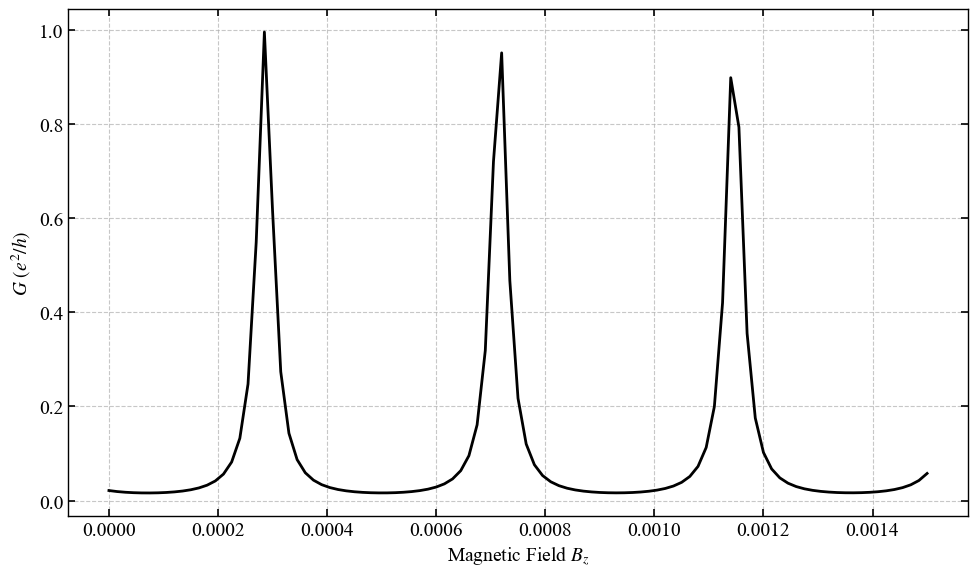

In [ ]:
# 设定固定的 E 和要扫描的 Bz 范围 多核心计算
E = 0.25
Bz0 = 0
Bz1 = 0.0015
dianshu = 101
Bz_values = np.linspace(Bz0, Bz1, dianshu)
eta = 1e-6

# 定义保存路径
save_dir = rf"C:\Users\taoji\Desktop\论文写作\2026.5.13"
params_str_1 = f"t={t}_tc={tc}_u={mu}_kuandu={kuandu}_leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}_E={E}"


print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...")

# ==========================================
# 核心修改：将循环内的计算逻辑打包成一个独立函数
# ==========================================
def calc_single_Bz(Bz_1):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    # ⚠️ 如果正式算磁场，记得这里要更新右电极！(遵照你的要求，这里保持注释状态不动)
    # H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu)

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

# ==========================================
# 使用 joblib 的 Parallel 开启 14 个 Worker 同时跑
# ==========================================
G_values = Parallel(n_jobs=14)(
    delayed(calc_single_Bz)(Bz_1) for Bz_1 in tqdm(Bz_values, desc="Scanning Bz (Parallel)")
)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(10, 6)) 
plt.plot(Bz_values, G_values, linestyle='-', color='black', linewidth=2)

plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'$G \ (e^2/h)$', fontsize=14)
#plt.title(fr'GvsBz_{params_str_1}', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


# 保存图片
#save_fig_by_title_1('4')

# ----------------- 保存数据部分 -----------------
# 调用刚才写好的数据保存函数


# 显示图像
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from joblib import Parallel, delayed
from tqdm import tqdm

# ==========================================
# 物理期刊全局格式设置
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.rcParams['mathtext.fontset'] = 'stix'        
plt.rcParams['xtick.direction'] = 'in'           
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.linewidth'] = 1.0             

# ==========================================
# 矩阵信息与系统参数
# ==========================================
t = 1
mu = 2.5
weidu = 2
kuandu = 2   # 电极的横向宽度
Nd = 2       # 2x2 正常态

# 预生成的电极哈密顿量
H_l = H_onsite_2(t, mu, weidu, kuandu)
T_l = H_hop_2(t, kuandu)
H_r = H_onsite_2(t, mu, weidu, kuandu)
T_r = H_hop_2(t, kuandu).conj().T

# 设定固定的 E 和要扫描的 Bz 范围
E = 0.25
Bz0 = 0
Bz1 = 0.0015
dianshu = 501
Bz_values = np.linspace(Bz0, Bz1, dianshu)
eta = 1e-6

# 定义保存路径
save_dir = r"C:\Users\taoji\Desktop\论文写作\2026.5.13"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# ==========================================
# 核心计算函数
# ==========================================
def calc_single_Bz(Bz_1, T_LD_local, T_RD_local):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD_local, T_l, T_RD_local, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

# ==========================================
# 🌟 核心修复：重新定义 tc_configs，补上 0.25, 0.5, 1.0
# ==========================================
tc_configs = [
    {'val': 1.0 * t,  'label': r'$t_c = t$'},
    {'val': 0.5 * t,  'label': r'$t_c = 0.5t$'},
    {'val': 0.25 * t, 'label': r'$t_c = 0.25t$'}
]

# 字典用于存储不同 tc 下计算出的电导数据
results_G = {}
print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算不同 tc 的电导 (并行)...")

# ==========================================
# 扫描循环
# ==========================================
for config in tc_configs:
    tc_current = config['val']
    label = config['label']
    
    # 构建当前 tc 对应的整体耦合块
    T_c = H_hop_2(tc_current, kuandu) 

    # 左电极耦合矩阵
    T_LD_current = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
    T_LD_current[:, -Nd * kuandu:] = T_c.conj().T

    # 右电极耦合矩阵
    T_RD_current = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
    T_RD_current[:, :Nd * kuandu] = T_c
    
    print(f"\n--- 正在计算 {label} ---")
    
    # 开启并行计算
    G_values = Parallel(n_jobs=14)(
        delayed(calc_single_Bz)(Bz_1, T_LD_current, T_RD_current) for Bz_1 in tqdm(Bz_values, desc=f"Scanning Bz")
    )
    
    results_G[label] = G_values

print("\n所有 tc 配置计算完成！")

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算不同 tc 的电导 (并行)...

--- 正在计算 $t_c = t$ ---


Scanning Bz: 100%|██████████| 501/501 [00:23<00:00, 21.54it/s]



--- 正在计算 $t_c = 0.5t$ ---


Scanning Bz: 100%|██████████| 501/501 [00:22<00:00, 21.94it/s]



--- 正在计算 $t_c = 0.25t$ ---


Scanning Bz: 100%|██████████| 501/501 [00:21<00:00, 23.19it/s]



所有 tc 配置计算完成！


In [22]:
from scipy.optimize import fmin

print("\n" + "="*55)
print("开始使用 fmin 重新调用底层物理模型计算精确周期 \u0394B ...")
print("（注意：这会重新计算格林函数，可能需要一点点时间，请耐心等待）")
print("="*55)

# 我们要找极值的两个初始猜测位置
target_1 = 0.0003
target_2 = 0.0007

# ==========================================
# 新增：创建一个列表来存所有的 delta_B，方便后续调用
# ==========================================
delta_B_list = []

# 遍历不同的 tc 配置
for i, config in enumerate(tc_configs):
    label = config['label']
    tc_current = config['val']
    
    # ==========================================
    # 1. 重建当前 tc 对应的电极耦合矩阵
    # ==========================================
    T_c = H_hop_2(tc_current, kuandu) 
    T_LD_current = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
    T_LD_current[:, -Nd * kuandu:] = T_c.conj().T
    T_RD_current = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
    T_RD_current[:, :Nd * kuandu] = T_c

    # ==========================================
    # 2. 定义目标连续函数 G(Bz)
    # ==========================================
    def G_of_Bz(bz_val):
        # fmin 传进来的可能是包含一个元素的数组，转成 float
        bz_scalar = float(bz_val)
        # 重新调用你最底层的 RGF 算法算出真实的电导
        G = calc_single_Bz(bz_scalar, T_LD_current, T_RD_current)
        # 因为 fmin 是求最小值，而我们找波峰，所以返回负的 G
        return -G
    
    print(f"正在寻找 {label} 的精确极值点...")
    
    # ==========================================
    # 3. 使用 fmin 动态计算寻优
    # ==========================================
    bz_peak_1 = fmin(G_of_Bz, target_1, disp=False, xtol=1e-8, ftol=1e-8)[0]
    bz_peak_2 = fmin(G_of_Bz, target_2, disp=False, xtol=1e-8, ftol=1e-8)[0]
    
    # 用后者减去前者得到周期
    delta_B = bz_peak_2 - bz_peak_1
    
    # ==========================================
    # 新增：将算出的周期存入列表
    # ==========================================
    delta_B_list.append(delta_B)
    
    # 输出，序号 i+1 刚好对应 ΔB1, ΔB2, ΔB3
    print(f"  峰值 1 (初始猜测 {target_1}) -> 算得精确 B_z1 = {bz_peak_1:.8f}")
    print(f"  峰值 2 (初始猜测 {target_2}) -> 算得精确 B_z2 = {bz_peak_2:.8f}")
    print(f"  ==> 周期 \u0394B{i+1} = {delta_B:.8f}\n")

print("="*55)
# 打印一下存好的列表，确认一下
print(f"全部计算完成！保存的周期列表 delta_B_list: {delta_B_list}")


开始使用 fmin 重新调用底层物理模型计算精确周期 ΔB ...
（注意：这会重新计算格林函数，可能需要一点点时间，请耐心等待）
正在寻找 $t_c = t$ 的精确极值点...


C:\Users\taoji\AppData\Local\Temp\ipykernel_13532\163055701.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bz_scalar = float(bz_val)


  峰值 1 (初始猜测 0.0003) -> 算得精确 B_z1 = 0.00030365
  峰值 2 (初始猜测 0.0007) -> 算得精确 B_z2 = 0.00073422
  ==> 周期 ΔB1 = 0.00043057

正在寻找 $t_c = 0.5t$ 的精确极值点...
  峰值 1 (初始猜测 0.0003) -> 算得精确 B_z1 = 0.00028354
  峰值 2 (初始猜测 0.0007) -> 算得精确 B_z2 = 0.00071356
  ==> 周期 ΔB2 = 0.00043003

正在寻找 $t_c = 0.25t$ 的精确极值点...
  峰值 1 (初始猜测 0.0003) -> 算得精确 B_z1 = 0.00028665
  峰值 2 (初始猜测 0.0007) -> 算得精确 B_z2 = 0.00071666
  ==> 周期 ΔB3 = 0.00043001

全部计算完成！保存的周期列表 delta_B_list: [0.0004305676269531251, 0.0004300256347656251, 0.0004300070190429688]


已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\4.png

图像已保存至: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\4.eps


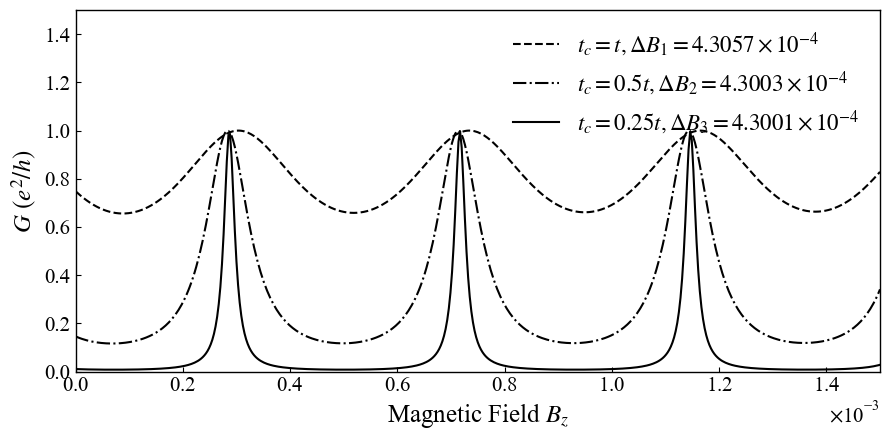

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 辅助函数：将小数转换为物理期刊标准的 LaTeX 科学计数法格式
# 例如: 0.00043043 -> 4.30 \times 10^{-4}
# ==========================================
def format_sci(val):
    sci_str = f"{val:.4e}"       # 转换为科学计数法字符串，保留两位小数 (如 '4.30e-04')
    mantissa, exp = sci_str.split('e')
    exp = int(exp)               # 去除前导零，例如 '-04' 变成 -4
    return fr"{mantissa} \times 10^{{{exp}}}"

# ==========================================
# 定义需要遍历的 tc 参数和对应的画图样式
# 结合辅助函数，自动生成类似于 \Delta B = 4.30 \times 10^{-4} 的优美标签
# ==========================================
tc_configs = [
    {'key': r'$t_c = t$',      'label': fr'$t_c = t, \Delta B_{1} = {format_sci(delta_B_list[0])}$',      'linestyle': '--'},  # 虚线
    {'key': r'$t_c = 0.5t$',   'label': fr'$t_c = 0.5t, \Delta B_{2} = {format_sci(delta_B_list[1])}$',   'linestyle': '-.'},  # 点划线
    {'key': r'$t_c = 0.25t$',  'label': fr'$t_c = 0.25t, \Delta B_{3} = {format_sci(delta_B_list[2])}$',  'linestyle': '-'}    # 黑实线
]

# ==========================================
# 画图部分 (物理期刊标准格式)
# ==========================================
fig, ax = plt.subplots(figsize=(9, 4.5))

# 遍历字典画图
for config in tc_configs:
    data_key = config['key']       # 用短名字去字典里拿数据
    display_label = config['label'] # 用带科学计数法的长名字画图例
    style = config['linestyle']
    
    ax.plot(Bz_values, results_G[data_key], linestyle=style, color='black', linewidth=1.5, label=display_label)

# ====== 字体放大 1.5 倍 ======
ax.set_xlabel(r'Magnetic Field $B_z$', fontsize=18)
ax.set_ylabel(r'$G \ (e^2/h)$', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

# 【核心美化】将 X 轴的坐标刻度也设为科学计数法 (例如 5 × 10^-4)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
# 为了配合科学计数法，调整下偏移量文字的位置，使其不与刻度重叠，字体放大 1.5 倍
ax.xaxis.get_offset_text().set_fontsize(15)

# 统一使用 ax.set_xlim 和 ax.set_ylim，代码更整洁不出错
ax.set_xlim(0, 0.0015) 
ax.set_ylim(0, 1.5)

# 将图例放在图内，并去掉边框，字体放大 1.5 倍
ax.legend(loc='upper right', frameon=False, fontsize=16.5)
# =============================

plt.tight_layout()

# 保存图片
filepath = os.path.join(save_dir, "4.eps")
save_fig_by_title_1('4') # 如果你需要的话，取消注释这行
plt.savefig(filepath, format='eps', dpi=300, bbox_inches='tight')
print(f"\n图像已保存至: {filepath}")

plt.show()

In [25]:
# ==========================================
# 设定 kuandu 需要遍历的参数配置 (固定 tc = 0.25*t)
# ==========================================
tc_fixed = 0.25 * t
dd=[2,8,20]
kuandu_configs = [
    {'val': dd[0], 'label': rf'$W = {dd[0]}$', 'linestyle': '-'},   # 实线
    {'val': dd[1], 'label': rf'$W = {dd[1]}$', 'linestyle': '--'},  # 虚线
    {'val': dd[2], 'label': rf'$W = {dd[2]}$', 'linestyle': '-.'}   # 点划线
]

# ==========================================
# 新的核心计算函数：将电极矩阵也作为参数传入，防止不同宽度的矩阵维度冲突
# ==========================================
def calc_single_Bz_kuandu(Bz_1, T_LD_local, T_RD_local, H_l_local, H_r_local, T_l_local, T_r_local):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    # 调用 Gr_DD_2 时，使用传进来的 local 电极矩阵
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l_local, H_r_local, T_21, T_LD_local, T_l_local, T_RD_local, T_r_local, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

# ==========================================
# 开始循环扫描不同的 kuandu
# ==========================================
results_G1 = {}  # 用新的字典，不和前者冲突

print(f"固定 E = {E}, tc = 0.25t, 开始扫描不同电极宽度 W 的电导 (并行)...")

for config in kuandu_configs:
    W_current = config['val']
    label = config['label']
    
    # 🌟 核心：因为宽度 W 变了，所以必须在这里重新生成电极自身的哈密顿量！
    H_l_current = H_onsite_2(t, mu, weidu, W_current)
    T_l_current = H_hop_2(t, W_current)
    H_r_current = H_onsite_2(t, mu, weidu, W_current)
    T_r_current = H_hop_2(t, W_current).conj().T
    
    # 构建当前宽度对应的整体耦合块
    T_c_current = H_hop_2(tc_fixed, W_current) 

    # 左电极耦合矩阵
    T_LD_current = np.zeros((Nd * W_current, Nd * xshumu), dtype=complex)
    T_LD_current[:, -Nd * W_current:] = T_c_current.conj().T

    # 右电极耦合矩阵
    T_RD_current = np.zeros((Nd * W_current, Nd * xshumu), dtype=complex)
    T_RD_current[:, :Nd * W_current] = T_c_current
    
    print(f"\n--- 正在计算 {label} ---")
    
    # 开启并行计算，将所有当前宽度对应的矩阵安全地传入 worker
    G_values = Parallel(n_jobs=14)(
        delayed(calc_single_Bz_kuandu)(
            Bz_1, T_LD_current, T_RD_current, H_l_current, H_r_current, T_l_current, T_r_current
        ) for Bz_1 in tqdm(Bz_values, desc=f"Scanning Bz (W={W_current})")
    )
    
    results_G1[label] = G_values

print("\n宽度扫描计算完成！结果已存入 results_G1。")

固定 E = 0.25, tc = 0.25t, 开始扫描不同电极宽度 W 的电导 (并行)...

--- 正在计算 $W = 2$ ---


Scanning Bz (W=2): 100%|██████████| 501/501 [00:21<00:00, 23.24it/s]



--- 正在计算 $W = 8$ ---


Scanning Bz (W=8): 100%|██████████| 501/501 [00:20<00:00, 24.08it/s]



--- 正在计算 $W = 20$ ---


Scanning Bz (W=20): 100%|██████████| 501/501 [00:21<00:00, 23.76it/s]



宽度扫描计算完成！结果已存入 results_G1。


In [26]:
from scipy.optimize import fmin

print("\n" + "="*55)
print("开始使用 fmin 计算不同宽度 W 的精确周期 \u0394B ...")
print("（注意：这会重新计算格林函数，可能需要一点点时间，请耐心等待）")
print("="*55)

# 我们要找极值的两个初始猜测位置
target_1 = 0.0003
target_2 = 0.0007

# ==========================================
# 新增：创建一个新列表来存不同宽度的 delta_B，不和前者冲突
# ==========================================
delta_B_list1 = []
tc_fixed = 0.25 * t  # 确保这里使用了固定的 tc

# 遍历不同的 kuandu (W) 配置
for i, config in enumerate(kuandu_configs):
    label = config['label']
    W_current = config['val']
    
    # ==========================================
    # 1. 重新生成当前宽度对应的所有电极矩阵！(防止维度崩溃)
    # ==========================================
    H_l_current = H_onsite_2(t, mu, weidu, W_current)
    T_l_current = H_hop_2(t, W_current)
    H_r_current = H_onsite_2(t, mu, weidu, W_current)
    T_r_current = H_hop_2(t, W_current).conj().T
    
    T_c_current = H_hop_2(tc_fixed, W_current) 

    # 左、右电极耦合矩阵
    T_LD_current = np.zeros((Nd * W_current, Nd * xshumu), dtype=complex)
    T_LD_current[:, -Nd * W_current:] = T_c_current.conj().T

    T_RD_current = np.zeros((Nd * W_current, Nd * xshumu), dtype=complex)
    T_RD_current[:, :Nd * W_current] = T_c_current

    # ==========================================
    # 2. 定义目标连续函数 G(Bz)
    # ==========================================
    def G_of_Bz(bz_val):
        bz_scalar = float(bz_val)
        # ⚠️ 核心：调用带 kuandu 后缀的新计算函数，并传入所有局部矩阵
        G = calc_single_Bz_kuandu(
            bz_scalar, T_LD_current, T_RD_current, 
            H_l_current, H_r_current, T_l_current, T_r_current
        )
        return -G
    
    print(f"正在寻找 {label} 的精确极值点...")
    
    # ==========================================
    # 3. 使用 fmin 动态计算寻优
    # ==========================================
    bz_peak_1 = fmin(G_of_Bz, target_1, disp=False, xtol=1e-8, ftol=1e-8)[0]
    bz_peak_2 = fmin(G_of_Bz, target_2, disp=False, xtol=1e-8, ftol=1e-8)[0]
    
    # 用后者减去前者得到周期
    delta_B = bz_peak_2 - bz_peak_1
    
    # ==========================================
    # 将算出的周期存入新的列表
    # ==========================================
    delta_B_list1.append(delta_B)
    
    # 输出结果
    print(f"  峰值 1 (初始猜测 {target_1}) -> 算得精确 B_z1 = {bz_peak_1:.8f}")
    print(f"  峰值 2 (初始猜测 {target_2}) -> 算得精确 B_z2 = {bz_peak_2:.8f}")
    print(f"  ==> 周期 \u0394B{i+1} = {delta_B:.8f}\n")

print("="*55)
# 打印一下存好的新列表，确认一下
print(f"全部计算完成！保存的新周期列表 delta_B_list1: {delta_B_list1}")


开始使用 fmin 计算不同宽度 W 的精确周期 ΔB ...
（注意：这会重新计算格林函数，可能需要一点点时间，请耐心等待）
正在寻找 $W = 2$ 的精确极值点...


C:\Users\taoji\AppData\Local\Temp\ipykernel_13532\426422396.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bz_scalar = float(bz_val)


  峰值 1 (初始猜测 0.0003) -> 算得精确 B_z1 = 0.00028665
  峰值 2 (初始猜测 0.0007) -> 算得精确 B_z2 = 0.00071666
  ==> 周期 ΔB1 = 0.00043001

正在寻找 $W = 8$ 的精确极值点...
  峰值 1 (初始猜测 0.0003) -> 算得精确 B_z1 = 0.00030029
  峰值 2 (初始猜测 0.0007) -> 算得精确 B_z2 = 0.00073033
  ==> 周期 ΔB2 = 0.00043003

正在寻找 $W = 20$ 的精确极值点...
  峰值 1 (初始猜测 0.0003) -> 算得精确 B_z1 = 0.00032704
  峰值 2 (初始猜测 0.0007) -> 算得精确 B_z2 = 0.00075711
  ==> 周期 ΔB3 = 0.00043007

全部计算完成！保存的新周期列表 delta_B_list1: [0.0004300070190429688, 0.00043003295898437493, 0.0004300732421875]


已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\5.png

不同宽度 W 的电导图像已保存至: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\5.eps


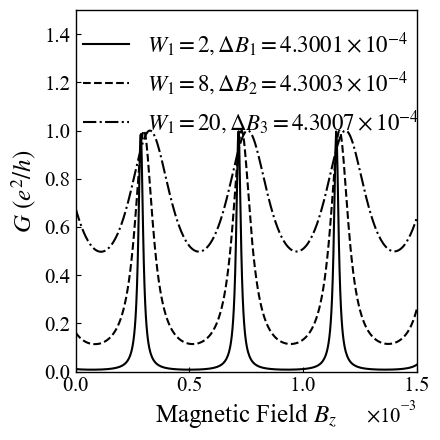

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 辅助函数：将小数转换为物理期刊标准的 LaTeX 科学计数法格式
# ==========================================
def format_sci(val):
    sci_str = f"{val:.4e}"       # 转换为科学计数法字符串，保留四位小数 (如 '4.3000e-04')
    mantissa, exp = sci_str.split('e')
    exp = int(exp)               # 去除前导零，例如 '-04' 变成 -4
    return fr"{mantissa} \times 10^{{{exp}}}"

# ==========================================
# 定义需要遍历的 kuandu (W) 参数和对应的画图样式
# 提取 delta_B_list1 里的数据
# ==========================================
kuandu_configs = [
    {'key': rf'$W = {dd[0]}$', 'label': fr'$W_{1} = {dd[0]}, \Delta B_{1} = {format_sci(delta_B_list1[0])}$', 'linestyle': '-'},   # 实线
    {'key': rf'$W = {dd[1]}$', 'label': fr'$W_{1} = {dd[1]}, \Delta B_{2} = {format_sci(delta_B_list1[1])}$', 'linestyle': '--'},  # 虚线
    {'key': rf'$W = {dd[2]}$', 'label': fr'$W_{1} = {dd[2]}, \Delta B_{3} = {format_sci(delta_B_list1[2])}$', 'linestyle': '-.'}   # 点划线
]

# ==========================================
# 画图部分 (物理期刊标准格式)
# ==========================================
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# 遍历字典画图 (⚠️ 注意这里使用的是 results_G1)
for config in kuandu_configs:
    data_key = config['key']       # 用短名字去字典里拿数据
    display_label = config['label'] # 用带科学计数法的长名字画图例
    style = config['linestyle']
    
    ax.plot(Bz_values, results_G1[data_key], linestyle=style, color='black', linewidth=1.5, label=display_label)

# ====== 字体放大 1.5 倍 ======
ax.set_xlabel(r'Magnetic Field $B_z$', fontsize=18)
ax.set_ylabel(r'$G \ (e^2/h)$', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

# 【核心美化】将 X 轴的坐标刻度设为科学计数法
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
# 调整偏移量文字的位置，使其不与刻度重叠，字体放大 1.5 倍
ax.xaxis.get_offset_text().set_fontsize(15)

# 统一使用 ax.set_xlim 和 ax.set_ylim
ax.set_xlim(0, 0.0015) 
ax.set_ylim(0, 1.5)

# 将图例放在图内，并去掉边框，字体放大 1.5 倍
ax.legend(loc='upper right', 
          bbox_to_anchor=(1.07, 1.0), 
          frameon=False, 
          fontsize=16.5) # 保持您之前的 1.5 倍放缩
# =============================

plt.tight_layout()

# 保存图片 (改为 5.eps 避免覆盖你刚才画的 4.eps)
filepath = os.path.join(save_dir, "5.eps")
# 如果你有这个自定义函数，取消注释：
save_fig_by_title_1('5') 

plt.savefig(filepath, format='eps', dpi=300, bbox_inches='tight')
print(f"\n不同宽度 W 的电导图像已保存至: {filepath}")

plt.show()

In [38]:
# ==========================================
# 矩阵信息与系统参数 (更新无序强度)
# ==========================================
t = 1
mu = 2.5
weidu = 2
kuandu = 2   
Nd = 2       
W_wuxu = 0.05

# ... (H_l, T_l 等预生成部分保持不动) ...

E = 0.25
Bz0 = 0
Bz1 = 0.0015
dianshu = 501
Bz_values = np.linspace(Bz0, Bz1, dianshu)
eta = 1e-6

# ==========================================
# 核心计算函数 (更新：每个 Bz 实时生成随机无序)
# ==========================================
def calc_single_Bz(Bz_1, T_LD_local, T_RD_local, W_val):
    # 🎯 核心修正：每计算一个 Bz 都会在此重新生成 50x50 的随机无序地貌
    # 这里的 yshumu 和 xshumu 应为 50
    current_disorder = (np.random.rand(yshumu, xshumu) - 0.5) * W_val
    
    H_q_list = []
    for i in range(yshumu):
        # 叠加当前层对应的随机无序到势能上
        uS_slice = uS_set_base + current_disorder[i, :]
        H_q_i = H_onstie(m, B, a, uS_slice, xshumu, Nd, A)
        H_q_list.append(H_q_i)
        
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    # 调用递归格林函数模块
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD_local, T_l, T_RD_local, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

# ==========================================
# tc_configs 定义保持不动
# ==========================================
tc_configs = [
    {'val': 1.0 * t,  'label': r'$t_c = t$'},
    {'val': 0.5 * t,  'label': r'$t_c = 0.5t$'},
    {'val': 0.25 * t, 'label': r'$t_c = 0.25t$'}
]

results_G_2 = {}
print(f"固定 E = {E}, 动态无序 W = {W_wuxu}, 开始计算不同 tc 的电导 (并行)...")

# ==========================================
# 扫描循环
# ==========================================
for config in tc_configs:
    tc_current = config['val']
    label = config['label']
    
    T_c = H_hop_2(tc_current, kuandu) 
    T_LD_current = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
    T_LD_current[:, -Nd * kuandu:] = T_c.conj().T
    T_RD_current = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
    T_RD_current[:, :Nd * kuandu] = T_c
    
    print(f"\n--- 正在计算 {label} ---")
    
    # 开启并行计算，传入 W_wuxu 作为强度参数
    G_values = Parallel(n_jobs=14)(
        delayed(calc_single_Bz)(Bz_1, T_LD_current, T_RD_current, W_wuxu) 
        for Bz_1 in tqdm(Bz_values, desc=f"Scanning Bz")
    )
    
    results_G_2[label] = G_values

print("\n所有配置（含每点随机无序）计算完成！结果已存入 results_G_2")

固定 E = 0.25, 动态无序 W = 0.05, 开始计算不同 tc 的电导 (并行)...

--- 正在计算 $t_c = t$ ---


Scanning Bz: 100%|██████████| 501/501 [00:20<00:00, 24.55it/s]



--- 正在计算 $t_c = 0.5t$ ---


Scanning Bz: 100%|██████████| 501/501 [00:20<00:00, 24.05it/s]



--- 正在计算 $t_c = 0.25t$ ---


Scanning Bz: 100%|██████████| 501/501 [00:20<00:00, 24.35it/s]



所有配置（含每点随机无序）计算完成！结果已存入 results_G_2


已保存图片: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\7.png

图像已保存至: C:\Users\taoji\Desktop\论文写作\2026.4.26\图\7.eps


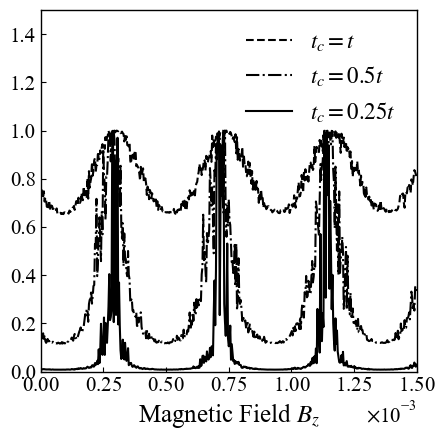

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 辅助函数：将小数转换为物理期刊标准的 LaTeX 科学计数法格式
# 例如: 0.00043043 -> 4.30 \times 10^{-4}
# ==========================================
def format_sci(val):
    sci_str = f"{val:.4e}"       # 转换为科学计数法字符串，保留两位小数 (如 '4.30e-04')
    mantissa, exp = sci_str.split('e')
    exp = int(exp)               # 去除前导零，例如 '-04' 变成 -4
    return fr"{mantissa} \times 10^{{{exp}}}"

# ==========================================
# 定义需要遍历的 tc 参数和对应的画图样式
# 结合辅助函数，自动生成类似于 \Delta B = 4.30 \times 10^{-4} 的优美标签
# ==========================================
tc_configs = [
    {'key': r'$t_c = t$',      'label': fr'$t_c = t$',      'linestyle': '--'},  # 虚线
    {'key': r'$t_c = 0.5t$',   'label': fr'$t_c = 0.5t$',   'linestyle': '-.'},  # 点划线
    {'key': r'$t_c = 0.25t$',  'label': fr'$t_c = 0.25t$',  'linestyle': '-'}    # 黑实线
]

# ==========================================
# 画图部分 (物理期刊标准格式)
# ==========================================
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# 遍历字典画图
for config in tc_configs:
    data_key = config['key']       # 用短名字去字典里拿数据
    display_label = config['label'] # 用带科学计数法的长名字画图例
    style = config['linestyle']
    
    ax.plot(Bz_values, results_G_2[data_key], linestyle=style, color='black', linewidth=1.5, label=display_label)

# ====== 字体放大 1.5 倍 ======
ax.set_xlabel(r'Magnetic Field $B_z$', fontsize=18)
#ax.set_ylabel(r'$G \ (e^2/h)$', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

# 【核心美化】将 X 轴的坐标刻度也设为科学计数法 (例如 5 × 10^-4)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
# 为了配合科学计数法，调整下偏移量文字的位置，使其不与刻度重叠，字体放大 1.5 倍
ax.xaxis.get_offset_text().set_fontsize(15)

# 统一使用 ax.set_xlim 和 ax.set_ylim，代码更整洁不出错
ax.set_xlim(0, 0.0015) 
ax.set_ylim(0, 1.5)

# 将图例放在图内，并去掉边框，字体放大 1.5 倍
ax.legend(loc='upper right', frameon=False, fontsize=16.5)
# =============================

plt.tight_layout()

# 保存图片
filepath = os.path.join(save_dir, "7.eps")
save_fig_by_title_1('7') # 如果你需要的话，取消注释这行
plt.savefig(filepath, format='eps', dpi=300, bbox_inches='tight')
print(f"\n图像已保存至: {filepath}")

plt.show()